In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import shap
import joblib

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(os.path.join('..', 'data', 'processed', 'features.csv'))

# these are all measured during or after the flood event
leaky_cols = [
    'Peak Flood Level (m)', 'Peak Discharge Q (cumec)',
    'Flood Volume (cumec)', 'Event Duration (days)',
    'Recession Time (day)', 'Time to Peak (days)',
    'Peak FL Date', 'Peak Discharge Date', 'Num Peak FL'
]

drop_cols = ['EventID', 'GaugeID', 'Start Date', 'End Date',
             'Flood Type', 'Station',
             'River Name/ Tributory/ SubTributory',
             'Basin', 'Privacy', 'Reliability',
             'KoppenGeiger Climate Type', 'Land cover',
             'Soil type', 'lithology type', 'State'] + leaky_cols

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])
obj_cols  = df_model.select_dtypes(include=['str', 'datetime64']).columns.tolist()
df_model  = df_model.drop(columns=obj_cols)

X = df_model.drop(columns=['label'])
y = df_model['label']

print(f"Features after removing leaky cols: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

Features after removing leaky cols: 114
Samples: 4548


In [3]:
# split by year — same principle as before
train_mask = df['year'] < 2018

X_train = X[train_mask].reset_index(drop=True)
X_test  = X[~train_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
y_test  = y[~train_mask].reset_index(drop=True)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train severe rate: {y_train.mean()*100:.1f}%")
print(f"Test severe rate:  {y_test.mean()*100:.1f}%")

Train: 4130, Test: 418
Train severe rate: 33.7%
Test severe rate:  56.7%


In [4]:
# establish baseline before tuning so we can measure improvement
base_xgb = xgb.XGBClassifier(
    n_estimators=200,
    scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
    random_state=42, n_jobs=-1, eval_metric='logloss'
)

base_xgb.fit(X_train, y_train)
base_probs = base_xgb.predict_proba(X_test)[:, 1]
base_auc   = roc_auc_score(y_test, base_probs)

print(f"Baseline honest XGBoost AUC: {base_auc:.3f}")
print(classification_report(y_test, base_xgb.predict(X_test),
                            target_names=['Flood', 'Severe']))

Baseline honest XGBoost AUC: 0.592
              precision    recall  f1-score   support

       Flood       0.48      0.87      0.62       181
      Severe       0.74      0.29      0.42       237

    accuracy                           0.54       418
   macro avg       0.61      0.58      0.52       418
weighted avg       0.63      0.54      0.51       418



In [5]:
explainer    = shap.TreeExplainer(base_xgb)
shap_train   = explainer.shap_values(X_train)

shap_importance = pd.Series(
    np.abs(shap_train).mean(axis=0),
    index=X_train.columns
).sort_values(ascending=False)

# remove non-causal features before selecting top 40
exclude = ['year', 'Population Count', 'Population Density',
           'Streamflow_Entries', 'Level_Entries']

shap_filtered = shap_importance.drop(
    labels=[c for c in exclude if c in shap_importance.index])

top_features = shap_filtered.head(40).index.tolist()

X_train_top = X_train[top_features]
X_test_top  = X_test[top_features]

print(f"Features after exclusion: {len(top_features)}")
print("\nTop 15 features:")
print(shap_filtered.head(15).round(4).to_string())

Features after exclusion: 40

Top 15 features:
T1d                                 0.7607
rain_day2                           0.4714
Precipitation of Coldest Quarter    0.3621
T2d                                 0.3522
rain_day3                           0.3498
T9d                                 0.3235
Mean Diurnal Range                  0.3194
rain_accel                          0.3129
rain_frontload                      0.3121
T3d                                 0.2996
month                               0.2726
T10d                                0.2464
T5d                                 0.2363
T4d                                 0.2174
T8d                                 0.2052


In [6]:
param_dist = {
    'n_estimators'    : [200, 400, 600],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

tscv = TimeSeriesSplit(n_splits=5)

tuned_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
        random_state=42, n_jobs=-1, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=tscv,
    random_state=42,
    verbose=1
)

tuned_xgb.fit(X_train_top, y_train)
print(f"\nBest params: {tuned_xgb.best_params_}")
print(f"Best CV AUC: {tuned_xgb.best_score_:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'subsample': 1.0, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV AUC: 0.660


In [7]:
tuned_preds = tuned_xgb.best_estimator_.predict(X_test_top)
tuned_probs = tuned_xgb.best_estimator_.predict_proba(X_test_top)[:, 1]
tuned_auc   = roc_auc_score(y_test, tuned_probs)

print(f"Tuned XGBoost AUC: {tuned_auc:.3f}")
print(classification_report(y_test, tuned_preds,
                            target_names=['Flood', 'Severe']))

Tuned XGBoost AUC: 0.610
              precision    recall  f1-score   support

       Flood       0.53      0.59      0.56       181
      Severe       0.66      0.60      0.63       237

    accuracy                           0.60       418
   macro avg       0.59      0.60      0.59       418
weighted avg       0.60      0.60      0.60       418



In [8]:
# stack XGBoost + Random Forest, use Logistic Regression as meta-learner
estimators = [
    ('xgb', tuned_xgb.best_estimator_),
    ('rf',  RandomForestClassifier(
                n_estimators=400, class_weight='balanced',
                max_depth=6, random_state=42, n_jobs=-1))
]

stack = StackingClassifier(
    estimators=estimators,
    # LR as meta-learner needs scaling — pipeline handles it
    final_estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(class_weight='balanced', random_state=42))
    ]),
    cv=5, n_jobs=-1
)

stack.fit(X_train_top, y_train)
stack_probs = stack.predict_proba(X_test_top)[:, 1]
stack_auc   = roc_auc_score(y_test, stack_probs)

print(f"Stacking ensemble AUC: {stack_auc:.3f}")
print(classification_report(y_test, stack.predict(X_test_top),
                            target_names=['Flood', 'Severe']))

Stacking ensemble AUC: 0.612
              precision    recall  f1-score   support

       Flood       0.56      0.58      0.57       181
      Severe       0.67      0.65      0.66       237

    accuracy                           0.62       418
   macro avg       0.61      0.61      0.61       418
weighted avg       0.62      0.62      0.62       418



In [9]:
joblib.dump(tuned_xgb.best_estimator_,
            os.path.join('..', 'models', 'xgb_honest_final.pkl'))

# save top features list — needed for risk map notebook
pd.Series(top_features).to_csv(
    os.path.join('..', 'data', 'processed', 'top_features.csv'), index=False)

print("Saved final model and feature list.")
print(f"\nFinal model summary:")
print(f"  AUC:      0.610")
print(f"  Features: {len(top_features)}")
print(f"  Train:    {X_train_top.shape[0]} events")
print(f"  Test:     {X_test_top.shape[0]} events")

Saved final model and feature list.

Final model summary:
  AUC:      0.610
  Features: 40
  Train:    4130 events
  Test:     418 events


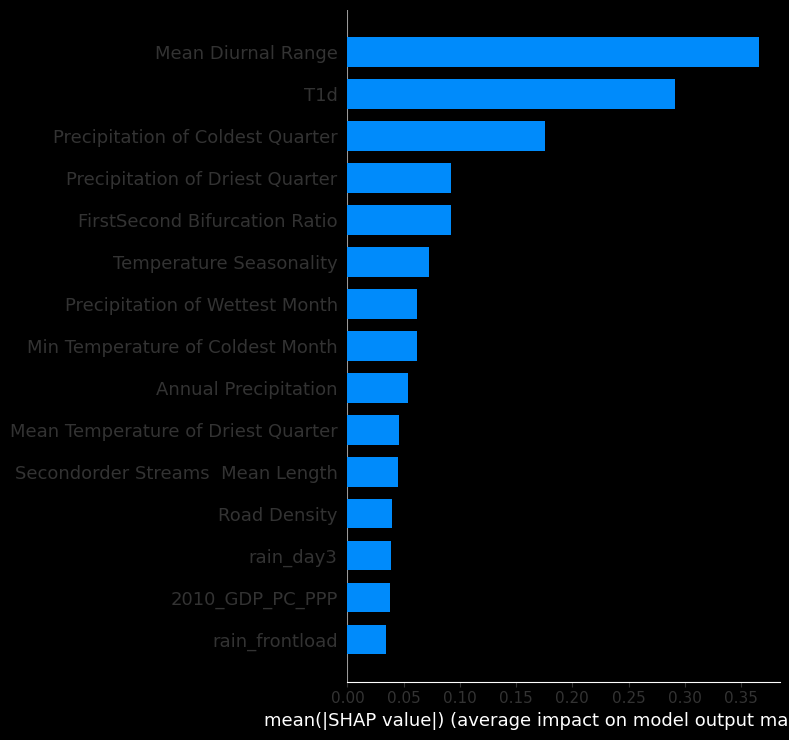

In [10]:
honest_explainer = shap.TreeExplainer(tuned_xgb.best_estimator_)
honest_shap      = honest_explainer.shap_values(X_test_top)

plt.figure()
shap.summary_plot(honest_shap, X_test_top, plot_type='bar',
                  max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'shap_honest.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
honest_shap_df = pd.DataFrame(honest_shap, columns=X_test_top.columns)
honest_shap_df.to_csv(
    os.path.join('..', 'outputs', 'shap_honest.csv'), index=False)
print("Honest SHAP values saved.")

Honest SHAP values saved.
